In [12]:
#imports
import pandas as pd
import matplotlib.pyplot as plt


# Investigate H1B Data for Rare Earth Mineral Keywords

In [13]:
df=pd.read_excel(r"C:\Users\linds\OneDrive\Documents\Unidos\LCA_Disclosure_Data_FY2022_Q1.xlsx")

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Software Developers, Applications'),
  Text(1, 0, 'Software Developers, Systems Software'),
  Text(2, 0, 'Computer Systems Analysts'),
  Text(3, 0, 'Computer Systems Engineers/Architects'),
  Text(4, 0, 'Computer and Information Systems Managers'),
  Text(5, 0, 'Database Administrators'),
  Text(6, 0, 'Software Quality Assurance Engineers and Testers'),
  Text(7, 0, 'Information Technology Project Managers'),
  Text(8, 0, 'Business Intelligence Analysts'),
  Text(9, 0, 'Operations Research Analysts'),
  Text(10, 0, 'Mechanical Engineers'),
  Text(11, 0, 'Statisticians'),
  Text(12, 0, 'Computer Occupations, All Other'),
  Text(13, 0, 'Electronics Engineers, Except Computer'),
  Text(14, 0, 'Computer Programmers')])

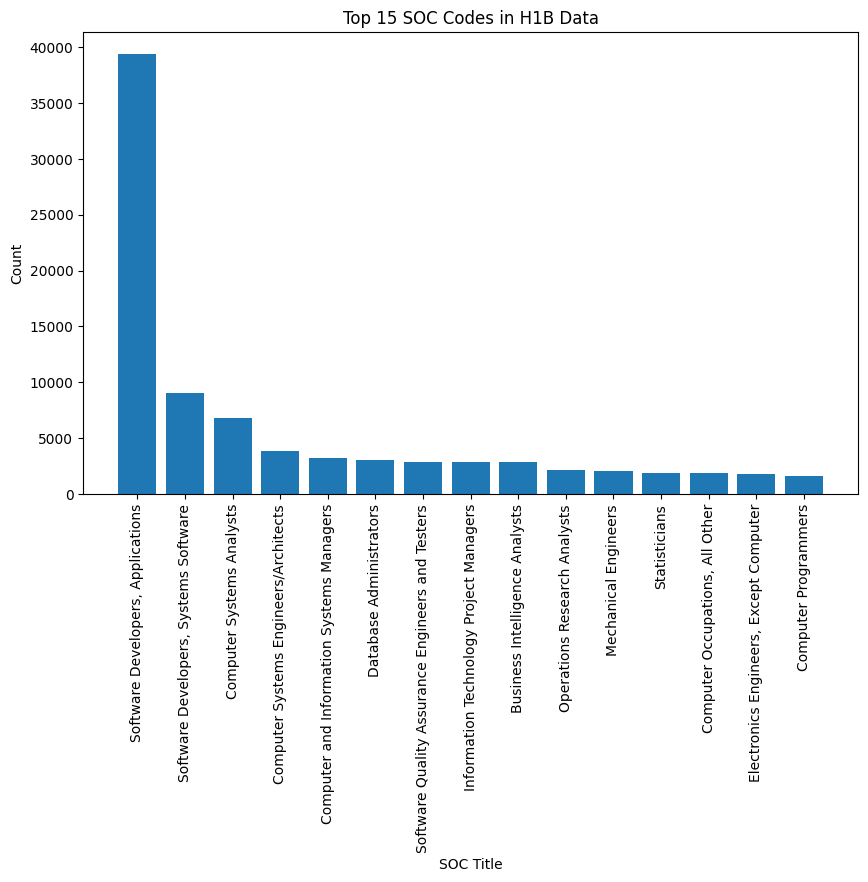

In [14]:
#Histogram of top 20 SOC codes

plt.figure(figsize=(10,6))
plt.bar(df['SOC_TITLE'].value_counts().head(15).index, df['SOC_TITLE'].value_counts().head(15).values)
plt.xlabel('SOC Title')
plt.ylabel('Count')
plt.title('Top 15 SOC Codes in H1B Data')
plt.xticks(rotation=90)

In [15]:
soc_codes = ['17-2151.00', '17-2131.00', '19-2042.00', '19-4042.00', '17-2081.00', '17-3025.00', '11-9041.00', '11-9121.00', '47-1011.00', '47-5022.00', '47-5023.00', '47-5032.00', '47-5043.00', '47-5044.00', '47-5049.00', '47-5081.00', '47-5012.00', '51-9021.00', '51-9012.00', '51-9011.00', '51-4051.00', '51-8099.00']

naics_codes = ['212290', '212230', '331410', '213114', '212390', '212291']

soc_code_related = df[df['SOC_CODE'].isin(soc_codes) & df['NAICS_CODE'].astype(str).isin(naics_codes)]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Electrical Engineer II'),
  Text(1, 0, 'Metallurgist II'),
  Text(2, 0, 'Senior Metallurgist'),
  Text(3, 0, 'Chief Engineer - Planning'),
  Text(4, 0, 'Senior Geotechnical Engineer'),
  Text(5, 0, 'Project Engineer I'),
  Text(6, 0, 'Geophysical Logging Engineer '),
  Text(7, 0, 'Director, Processing'),
  Text(8, 0, 'Mine Engineer I'),
  Text(9, 0, 'Mechanical Engineer II'),
  Text(10, 0, 'Mine Engineer II'),
  Text(11, 0, 'Senior Engineer'),
  Text(12, 0, 'Senior Process Automation Engineer'),
  Text(13, 0, 'Group Executive, VALUE ASSURANCE'),
  Text(14, 0, 'DIRECTOR, CATEGORY MANAGEMENT')])

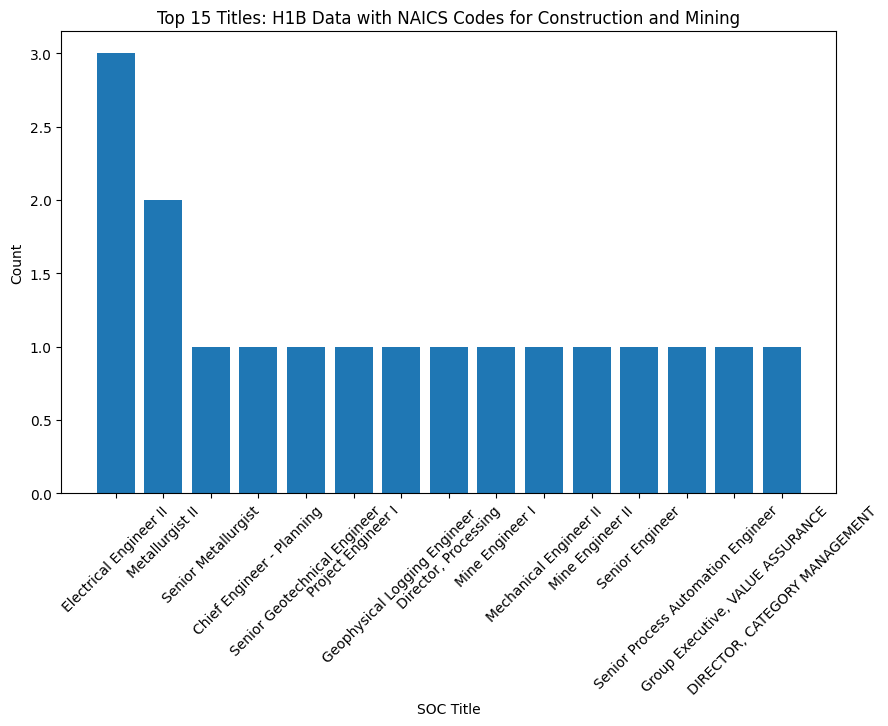

In [16]:
naics_cm_codes_df=df[df['NAICS_CODE'].astype(str).isin(naics_codes)]
plt.figure(figsize=(10,6))
plt.bar(naics_cm_codes_df['JOB_TITLE'].value_counts().head(15).index, naics_cm_codes_df['JOB_TITLE'].value_counts().head(15).values)
plt.xlabel('SOC Title')
plt.ylabel('Count')
plt.title('Top 15 Titles: H1B Data with NAICS Codes for Construction and Mining')
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Metallurgist II'),
  Text(1, 0, 'Geophysical Logging Engineer '),
  Text(2, 0, 'Senior Metallurgist'),
  Text(3, 0, 'Senior Geotechnical Engineer'),
  Text(4, 0, 'Director, Processing'),
  Text(5, 0, 'Mine Engineer I'),
  Text(6, 0, 'Mine Engineer II')])

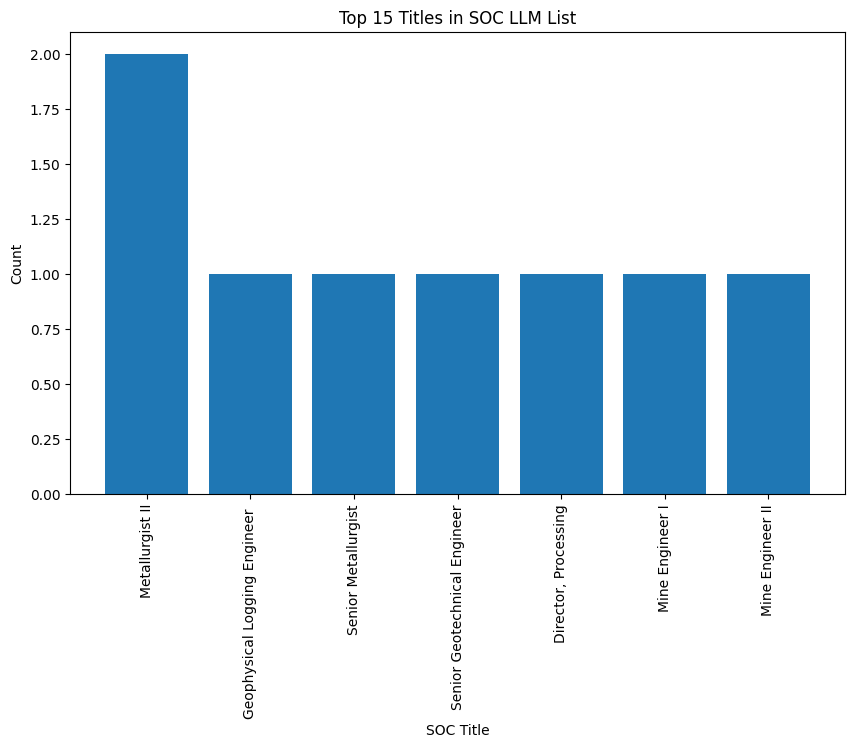

In [17]:
plt.figure(figsize=(10,6))
plt.bar(soc_code_related['JOB_TITLE'].value_counts().head(15).index, soc_code_related['JOB_TITLE'].value_counts().head(15).values)
plt.xlabel('SOC Title')
plt.ylabel('Count')
plt.title('Top 15 Titles in SOC LLM List')
plt.xticks(rotation=90)

In [18]:
import re

# 1. The "Wide Net" Regex Pattern (Includes broad minerals)
pattern = (
    # Group A: Broad Industry Terms & Recycling
    r'(?i)(critical mineral|critical material|strategic mineral|strategic material|'
    r'battery metal|battery material|energy metal|technology metal|battery recycling|black mass|'
    
    # Group B: Processing & Extraction Jargon
    r'extractive|hydrometallurg|pyrometallurg|solvent extraction|beneficiation|'
    r'leaching|bioleaching|separation engineer|separation scientist|metallurgist|'
    r'mineral processing|direct lithium extraction|\bDLE\b|electrowinning|electrorefining|'
    r'froth flotation|ion exchange|comminution|calcination|'
    
    # Group C: Rare Earth minerals
    r'rare earth|lanthanide|neodymium|praseodymium|dysprosium|terbium|scandium|yttrium|'
    r'cerium|lanthanum|samarium|europium|gadolinium|holmium|erbium|thulium|ytterbium|lutetium|'
    r'lithium|cobalt|gallium|germanium|indium|tellurium|tantalum|niobium|'
    r'antimony|bismuth|beryllium|tungsten|vanadium|cesium|rubidium|hafnium|zirconium|'
    r'fluorspar|fluorine|barite|chromium|\btin\b|\barsenic\b|uranium|'
    r'platinum|palladium|iridium|rhodium|ruthenium|silicon carbide| eletrical steel|'
    r'copper|aluminum|zinc|graphite|nickel|manganese|magnesium|titanium|'
    r'electrical steel|phosphorus|'

    # Group D: Ores, Brines, & Key Compounds
    r'spodumene|brine|bastnaesite|monazite|laterite|lithium carbonate|lithium hydroxide|\bNdFeB\b)'
)

# 2. Extract the keywords found into a list so you know WHY a row was flagged
df['critical_mineral_keywords'] = df['JOB_TITLE'].str.findall(pattern).apply(
    lambda matches: [word for tuple_group in matches for word in tuple_group if word]
)

# 3. Create the filter column
df['is_critical_mineral_job'] = df['critical_mineral_keywords'].astype(bool)

# 4. View your results
wide_net_df = df[df['is_critical_mineral_job'] == True].copy()

# Print the top results to verify
print(wide_net_df[['JOB_TITLE', 'critical_mineral_keywords', 'EMPLOYER_NAME']].head(10))

                                         JOB_TITLE  \
3690                           Senior Metallurgist   
11764                          Senior Metallurgist   
41593                         Project Metallurgist   
42563                           Plant Metallurgist   
43773                              Metallurgist II   
48302  R&D Engineer/Scientist II- R&D Metallurgist   
53031        Manager, Strategic Materials Engineer   
55996                         Project Metallurgist   
69653       Heat Treat Engineer/Plant Metallurgist   
70918                           Plant Metallurgist   

                               critical_mineral_keywords  \
3690                [M, e, t, a, l, l, u, r, g, i, s, t]   
11764               [M, e, t, a, l, l, u, r, g, i, s, t]   
41593               [M, e, t, a, l, l, u, r, g, i, s, t]   
42563               [M, e, t, a, l, l, u, r, g, i, s, t]   
43773               [M, e, t, a, l, l, u, r, g, i, s, t]   
48302               [M, e, t, a, l, l, u, r, 

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Senior Metallurgist'),
  Text(1, 0, 'Project Metallurgist'),
  Text(2, 0, 'Plant Metallurgist'),
  Text(3, 0, 'Metallurgist Ii'),
  Text(4, 0, 'R D Engineer Scientist Ii R D Metallurgist'),
  Text(5, 0, 'Manager Strategic Materials Engineer'),
  Text(6, 0, 'Heat Treat Engineer Plant Metallurgist'),
  Text(7, 0, 'Commissioning Metallurgist'),
  Text(8, 0, 'Lithium Ion Cell Engineer')])

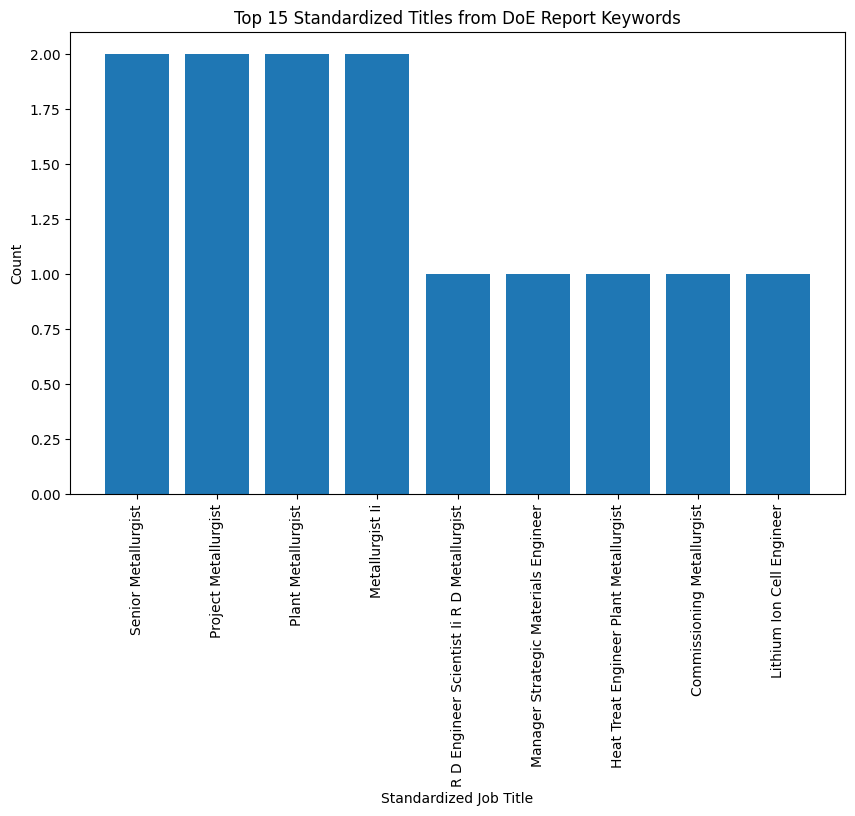

In [19]:
wide_net_df['JOB_TITLE_STD'] = (
    wide_net_df['JOB_TITLE']
    .fillna('')
    .str.lower()
    .str.replace(r'[^a-z0-9\s]', ' ', regex=True)
    .str.replace(r'\b(sr|snr)\b', 'senior', regex=True)
    .str.replace(r'\bjr\b', 'junior', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

top_titles = wide_net_df.loc[wide_net_df['JOB_TITLE_STD'] != '', 'JOB_TITLE_STD'].value_counts().head(15)

plt.figure(figsize=(10,6))
plt.bar(top_titles.index.str.title(), top_titles.values)
plt.xlabel('Standardized Job Title')
plt.ylabel('Count')
plt.title('Top 15 Standardized Titles from DoE Report Keywords')
plt.xticks(rotation=90)